In [1]:
# 1.  Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")


In [2]:
#  2. Load Dataset

train_df = pd.read_excel('../data/train_data.xlsx')
test_df  = pd.read_excel('../data/test_data.xlsx')


In [3]:
#  3. Understand the Data

train_df.head()


,year,month,day,order,country,session_id,page1_main_category,page2_clothing_model,colour,location,model_photography,price,price_2,page
0,2008,6,22,21,29,15648,3,C20,13,1,2,48,1,2
1,2008,5,19,6,29,10018,2,B26,13,3,1,57,1,2
2,2008,7,15,2,29,19388,3,C13,9,5,1,48,1,1
3,2008,5,2,2,29,7181,2,B11,2,4,1,43,2,1
4,2008,6,9,16,29,13493,2,B31,9,5,1,57,1,2


In [4]:

train_df.shape


(132379, 14)

In [5]:

train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132379 entries, 0 to 132378
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   year                  132379 non-null  int64 
 1   month                 132379 non-null  int64 
 2   day                   132379 non-null  int64 
 3   order                 132379 non-null  int64 
 4   country               132379 non-null  int64 
 5   session_id            132379 non-null  int64 
 6   page1_main_category   132379 non-null  int64 
 7   page2_clothing_model  132379 non-null  object
 8   colour                132379 non-null  int64 
 9   location              132379 non-null  int64 
 10  model_photography     132379 non-null  int64 
 11  price                 132379 non-null  int64 
 12  price_2               132379 non-null  int64 
 13  page                  132379 non-null  int64 
dtypes: int64(13), object(1)
memory usage: 14.1+ MB


In [6]:

train_df.describe()


,year,month,day,order,country,session_id,page1_main_category,colour,location,model_photography,price,price_2,page
count,132379.0,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000,132379.000000
mean,2008.0,5.582759,14.507671,9.811314,26.949629,12038.722063,2.400426,6.227393,3.261106,1.260026,43.788191,1.488484,1.712137
std,0.0,1.328064,8.829106,13.458937,7.153071,7012.460866,1.145004,4.238354,1.714058,0.438650,12.539390,0.499869,0.983699
min,2008.0,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,18.000000,1.000000,1.000000
25%,2008.0,4.000000,7.000000,2.000000,29.000000,5905.000000,1.000000,3.000000,2.000000,1.000000,33.000000,1.000000,1.000000
50%,2008.0,5.000000,14.000000,6.000000,29.000000,11931.000000,2.000000,4.000000,3.000000,1.000000,43.000000,1.000000,1.000000
75%,2008.0,7.000000,22.000000,12.000000,29.000000,18212.000000,3.000000,9.000000,5.000000,2.000000,52.000000,2.000000,2.000000
max,2008.0,8.000000,31.000000,195.000000,47.000000,24026.000000,4.000000,14.000000,6.000000,2.000000,82.000000,2.000000,5.000000


In [7]:
# 4. Check Missing Values

train_df.isnull().sum()

print("Missing values BEFORE cleaning:\n")
print(train_df.isnull().sum())


Missing values BEFORE cleaning:

year                    0
month                   0
day                     0
order                   0
country                 0
session_id              0
page1_main_category     0
page2_clothing_model    0
colour                  0
location                0
model_photography       0
price                   0
price_2                 0
page                    0
dtype: int64


In [8]:
#  5. Handle Missing Values

num_cols = train_df.select_dtypes(include=np.number).columns
cat_cols = train_df.select_dtypes(exclude=np.number).columns

# Numerical columns → Median
for col in num_cols:
    train_df[col].fillna(train_df[col].median(), inplace=True)
    test_df[col].fillna(test_df[col].median(), inplace=True)

# Categorical columns → Mode
for col in cat_cols:
    train_df[col].fillna(train_df[col].mode()[0], inplace=True)
    test_df[col].fillna(test_df[col].mode()[0], inplace=True)


In [9]:
# 6. Check Missing values (After)

print("\nMissing values AFTER cleaning:\n")
print(train_df.isnull().sum())



Missing values AFTER cleaning:

year                    0
month                   0
day                     0
order                   0
country                 0
session_id              0
page1_main_category     0
page2_clothing_model    0
colour                  0
location                0
model_photography       0
price                   0
price_2                 0
page                    0
dtype: int64


In [10]:
# 7. Confirmation Message 

if train_df.isnull().sum().sum() == 0:
    print("\n✅ All missing values successfully handled.")
else:
    print("\n⚠️ Missing values still exist.")



✅ All missing values successfully handled.


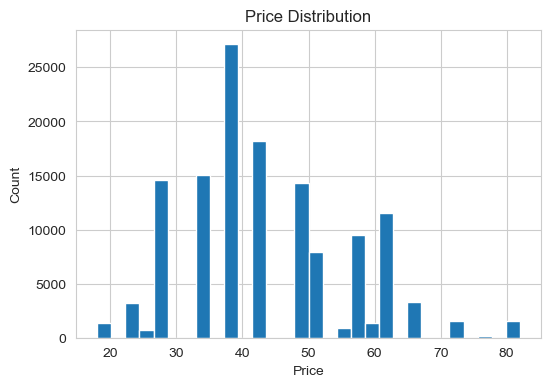

In [11]:
# 8. UNIVARIATE ANALYSIS 
# PRICE – Histogram

plt.figure(figsize=(6,4))
train_df['price'].hist(bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()


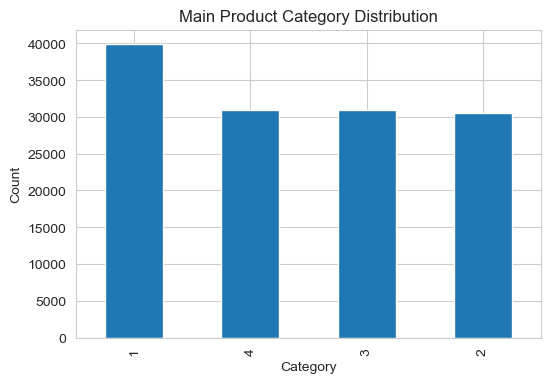

In [12]:
# MAIN CATEGORY – Bar Chart

plt.figure(figsize=(6,4))
train_df['page1_main_category'].value_counts().plot(kind='bar')
plt.title("Main Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()


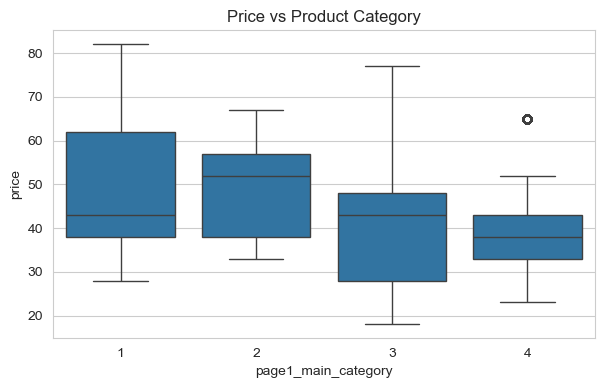

In [13]:
# 9.  BIVARIATE ANALYSIS (Two Columns)
# PRICE vs CATEGORY – Boxplot

plt.figure(figsize=(7,4))
sns.boxplot(x='page1_main_category', y='price', data=train_df)
plt.title("Price vs Product Category")
plt.show()


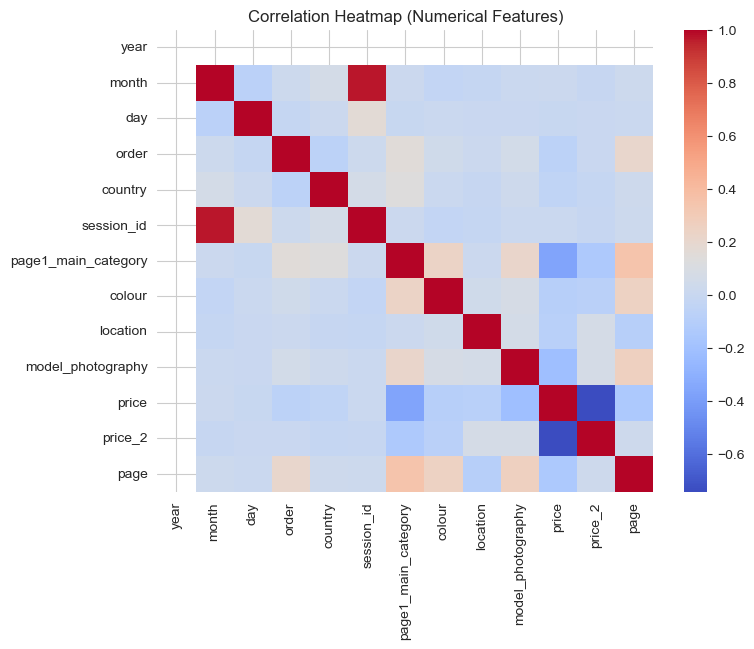

In [14]:
# 10. MULTIVARIATE ANALYSIS
# Correlation Heatmap (Numerical columns)

plt.figure(figsize=(8,6))

corr_matrix = train_df[num_cols].corr()

sns.heatmap(corr_matrix, cmap='coolwarm')
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


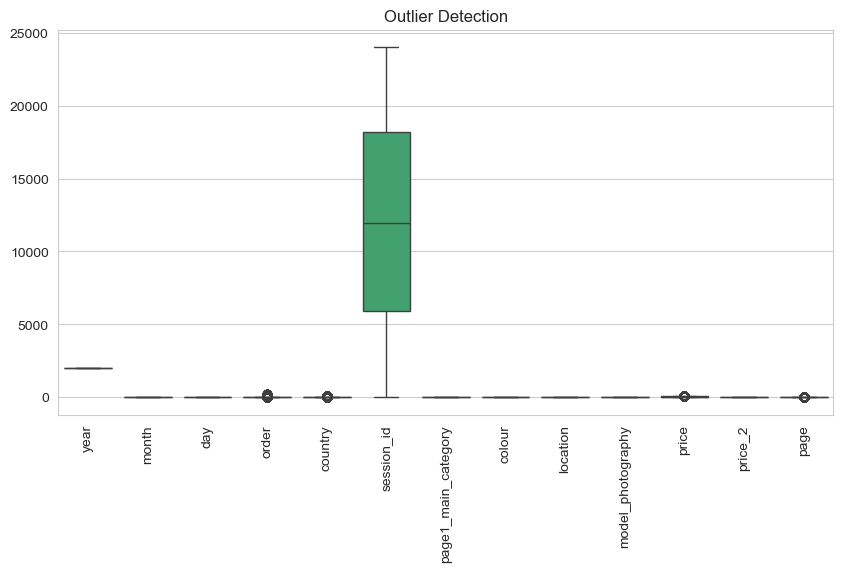

In [15]:
# 11. Outlier Check 

plt.figure(figsize=(10,5))
sns.boxplot(data=train_df[num_cols])
plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()


In [16]:
# 12. Save Cleaned Data

train_df.to_csv('../data/train_cleaned.csv', index=False)
test_df.to_csv('../data/test_cleaned.csv', index=False)

print("✅ train_cleaned.csv and test_cleaned.csv files saved successfully in data folder.")


✅ train_cleaned.csv and test_cleaned.csv files saved successfully in data folder.
